In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# Vai ler o arquivo CSV
df = pd.read_csv('consumo_original.csv')

# Para conferir as colunas (as 5 primeiras linhas)
df.head()

,id_cliente,tipo_cliente,porte_cliente,consumo_kwh,uso_horario_pico_horas,quantidade_equipamentos,tempo_medio_uso_diario,perfil_energetico
0,1,Residencial,Medio,210,0.7,23,7.0,Eficiente
1,2,Industrial,Pequeno,853,3.3,33,11.7,Moderado
2,3,Comercial,Pequeno,1091,3.5,35,13.9,Moderado
3,4,Residencial,Pequeno,324,0.7,24,8.7,Moderado
4,5,Residencial,Pequeno,182,1.9,21,2.2,Eficiente


In [ ]:
# Coloquei para ver quantos clientes temos para cada tipo
# Coloquei tambem para mostrar uma tabela mais limpa
print("--- Quantidade por Tipo de Cliente ---")
display(df['tipo_cliente'].value_counts().to_frame())

# Aqui é pra ver quantos clientes foram classificados em cada perfil
print("\n--- Quantidade por Perfil Energético ---")
display(df['perfil_energetico'].value_counts().to_frame())

--- Quantidade por Tipo de Cliente ---


,count
tipo_cliente,
Residencial,887
Comercial,460
Industrial,153



--- Quantidade por Perfil Energético ---


,count
perfil_energetico,
Moderado,1009
Eficiente,408
Ineficiente,83


C:\Users\camil\AppData\Local\Temp\ipykernel_20544\1229774274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='perfil_energetico', palette='dark', order=df['perfil_energetico'].value_counts().index)


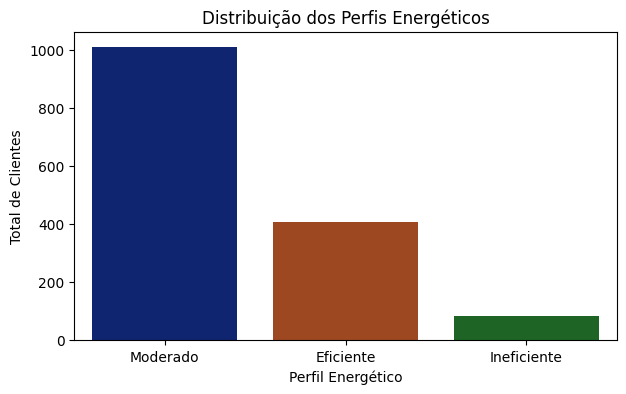

In [ ]:
# Espaço para o grafico
plt.figure(figsize=(7, 4))

# Criei um grafico de barras simples 
sns.countplot(data=df, x='perfil_energetico', palette='dark', order=df['perfil_energetico'].value_counts().index)

# Adicionei titulos para deixar mais organizado
plt.title('Distribuição dos Perfis Energéticos')
plt.xlabel('Perfil Energético')
plt.ylabel('Total de Clientes')

# Mostrar o gráfico final na tela
plt.show()

In [ ]:
# 1. Calcular a média e transformar em DataFrame
media_consumo = df.groupby('tipo_cliente')['consumo_kwh'].mean().to_frame()

# 2. Mudar o nome das colunas e eixos
media_consumo = media_consumo.rename(columns={'consumo_kwh': 'Consumo Médio'}).rename_axis('Tipo de Cliente')

# 3. Formatar os números para ficarem limpos e com "kWh" no final
media_consumo['Consumo Médio'] = media_consumo['Consumo Médio'].map('{:,.2f} kWh'.format)

# Mostrar a tabela
display(media_consumo)

,Consumo Médio
Tipo de Cliente,
Comercial,"9,733.88 kWh"
Industrial,"11,172.48 kWh"
Residencial,249.48 kWh
